🎰 BIASED CASINO GAME FAIRNESS ANALYSIS STARTED


SECTION 1 : BIASED DICE GAME SIMULATION

First 20 Dice Rolls:

[3 4 1 1 3 4 6 5 4 2 6 4 4 5 3 3 1 3 4 1]


SECTION 2 : OBSERVED vs EXPECTED FREQUENCIES

Dice Frequency Table:

 Dice Face  Observed Frequency  Expected Frequency  Difference
         1                2192         1666.666667  525.333333
         2                2212         1666.666667  545.333333
         3                1990         1666.666667  323.333333
         4                1847         1666.666667  180.333333
         5                 972         1666.666667 -694.666667
         6                 787         1666.666667 -879.666667


SECTION 3 : STATISTICAL ANALYSIS

Mean                 : 2.9556
Median               : 3.0
Standard Deviation   : 1.542
Variance             : 2.3778
Minimum Value        : 1
Maximum Value        : 6


SECTION 4 : CHI-SQUARE FAIRNESS TEST

Chi-Square Statistic : 1180.082
P-Value              : 6.05675884726124e-253

❌ RESULT : Dic

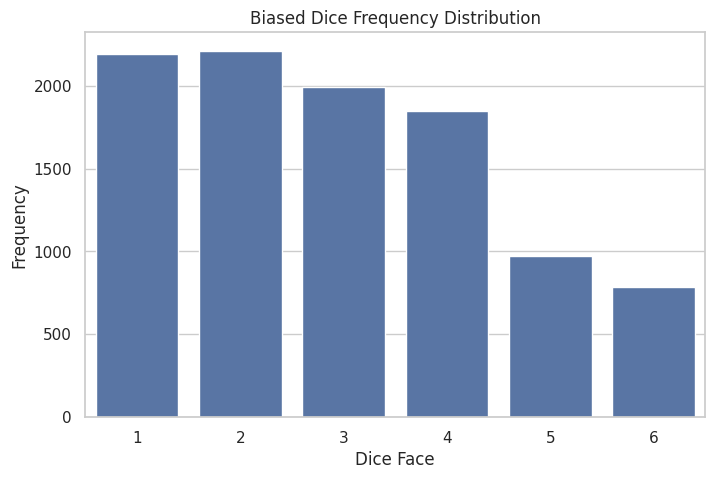

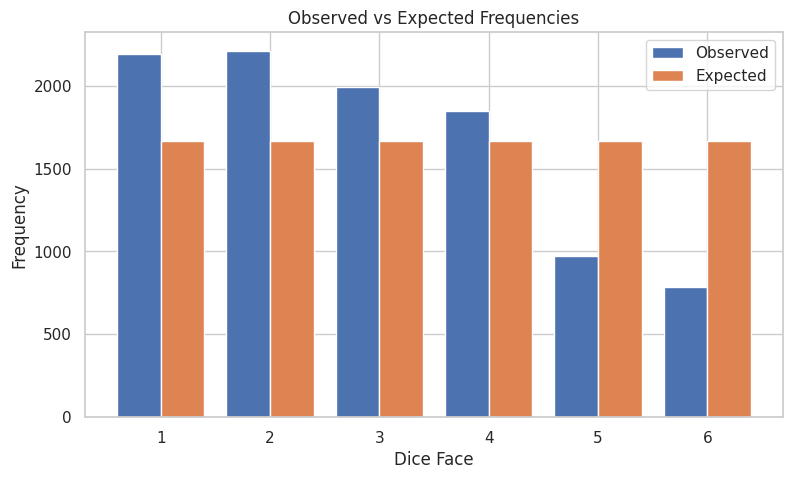



SECTION 8 : PLAYER vs CASINO PROFIT ANALYSIS


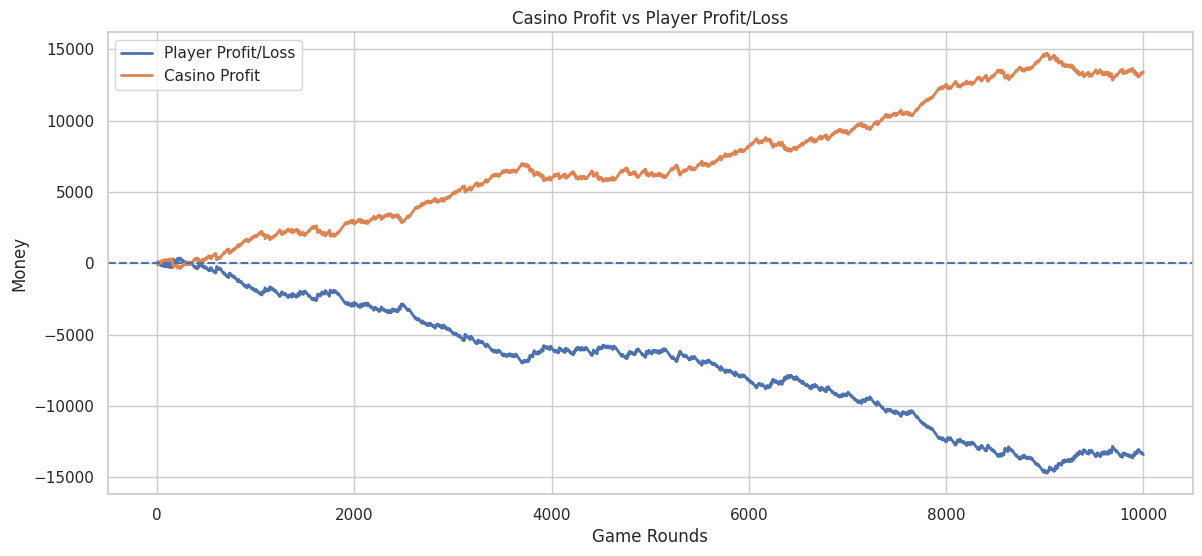



SECTION 9 : FINAL SUMMARY

Project Summary Table:

              Analysis    Status
Biased Dice Simulation Completed
  Statistical Analysis Completed
       Chi-Square Test Completed
                T-Test Completed
Monte Carlo Simulation Completed
Casino Profit Analysis Completed
   Graph Visualization Completed


SECTION 10 : FINAL CONCLUSION


PROJECT FINDINGS
----------------

1. The casino used a biased dice instead of a fair dice.

2. Lower dice faces appeared much more frequently than
   higher dice faces.

3. Chi-Square Test produced a very small P-Value,
   proving statistical unfairness.

4. T-Test showed that the dice mean significantly differs
   from the theoretical mean of a fair dice.

5. Monte Carlo simulation demonstrated continuous
   player losses and casino profit growth.

6. The winning probability was intentionally very low.

FINAL RESULT
------------

❌ THE CASINO GAME IS STATISTICALLY UNFAIR

The extremely small P-Value strongly rejects
the assumption of fairn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chisquare, ttest_1samp

sns.set(style="whitegrid")

print("="*85)
print("🎰 BIASED CASINO GAME FAIRNESS ANALYSIS STARTED")
print("="*85)

# ============================================================
# SECTION 1 : BIASED DICE SIMULATION
# ============================================================

print("\n")
print("="*85)
print("SECTION 1 : BIASED DICE GAME SIMULATION")
print("="*85)

num_rolls = 10000

dice_faces = [1, 2, 3, 4, 5, 6]

biased_probabilities = [
    0.22,
    0.22,
    0.20,
    0.18,
    0.10,
    0.08
]

dice_rolls = np.random.choice(
    dice_faces,
    size=num_rolls,
    p=biased_probabilities
)

print("\nFirst 20 Dice Rolls:\n")
print(dice_rolls[:20])

# ============================================================
# SECTION 2 : FREQUENCY ANALYSIS
# ============================================================

print("\n")
print("="*85)
print("SECTION 2 : OBSERVED vs EXPECTED FREQUENCIES")
print("="*85)

observed_counts = []

for face in dice_faces:
    observed_counts.append(np.sum(dice_rolls == face))

expected_frequency = num_rolls / 6

dice_df = pd.DataFrame({
    "Dice Face": dice_faces,
    "Observed Frequency": observed_counts,
    "Expected Frequency": [expected_frequency]*6
})

dice_df["Difference"] = (
    dice_df["Observed Frequency"]
    - dice_df["Expected Frequency"]
)

print("\nDice Frequency Table:\n")
print(dice_df.to_string(index=False))

# ============================================================
# SECTION 3 : STATISTICAL ANALYSIS
# ============================================================

print("\n")
print("="*85)
print("SECTION 3 : STATISTICAL ANALYSIS")
print("="*85)

mean_value = np.mean(dice_rolls)
median_value = np.median(dice_rolls)
std_value = np.std(dice_rolls)
variance_value = np.var(dice_rolls)

print("\nMean                 :", round(mean_value, 4))
print("Median               :", median_value)
print("Standard Deviation   :", round(std_value, 4))
print("Variance             :", round(variance_value, 4))
print("Minimum Value        :", np.min(dice_rolls))
print("Maximum Value        :", np.max(dice_rolls))

# ============================================================
# SECTION 4 : CHI-SQUARE TEST
# ============================================================

print("\n")
print("="*85)
print("SECTION 4 : CHI-SQUARE FAIRNESS TEST")
print("="*85)

chi_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=[expected_frequency]*6
)

print("\nChi-Square Statistic :", round(chi_stat, 4))
print("P-Value              :", p_value)

if p_value > 0.05:
    print("\n✅ RESULT : Dice appears FAIR")
else:
    print("\n❌ RESULT : Dice appears UNFAIR / BIASED")

# ============================================================
# SECTION 5 : T-TEST ANALYSIS
# ============================================================

print("\n")
print("="*85)
print("SECTION 5 : T-TEST ANALYSIS")
print("="*85)

expected_mean = 3.5

t_stat, t_pvalue = ttest_1samp(
    dice_rolls,
    expected_mean
)

print("\nExpected Mean :", expected_mean)

print("\nT-Statistic   :", round(t_stat, 4))
print("P-Value       :", t_pvalue)

if t_pvalue > 0.05:
    print("\n✅ Mean matches fair dice")
else:
    print("\n❌ Mean significantly differs from fair dice")

# ============================================================
# SECTION 6 : MONTE CARLO BETTING SIMULATION
# ============================================================

print("\n")
print("="*85)
print("SECTION 6 : MONTE CARLO BETTING SIMULATION")
print("="*85)

initial_money = 1000
money = initial_money

wins = 0
losses = 0

money_history = []

for roll in dice_rolls:

    if roll == 6:

        money += 100
        wins += 1

    else:

        money -= 10
        losses += 1

    money_history.append(money)

print("\nInitial Money :", initial_money)
print("Final Money   :", money)

print("\nWinning Rounds :", wins)
print("Losing Rounds  :", losses)

print("\nWinning Ratio  :", round((wins/num_rolls)*100, 2), "%")
print("Losing Ratio   :", round((losses/num_rolls)*100, 2), "%")

# ============================================================
# SECTION 7 : GRAPH VISUALIZATION
# ============================================================

print("\n")
print("="*85)
print("SECTION 7 : GRAPH VISUALIZATION")
print("="*85)

plt.figure(figsize=(8,5))

sns.barplot(
    x=dice_df["Dice Face"],
    y=dice_df["Observed Frequency"]
)

plt.title("Biased Dice Frequency Distribution")
plt.xlabel("Dice Face")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(9,5))

x = np.arange(1, 7)

plt.bar(
    x - 0.2,
    dice_df["Observed Frequency"],
    width=0.4,
    label="Observed"
)

plt.bar(
    x + 0.2,
    dice_df["Expected Frequency"],
    width=0.4,
    label="Expected"
)

plt.xticks(x)

plt.title("Observed vs Expected Frequencies")
plt.xlabel("Dice Face")
plt.ylabel("Frequency")

plt.legend()

plt.show()

# ============================================================
# SECTION 8 : PLAYER vs CASINO PROFIT ANALYSIS
# ============================================================

print("\n")
print("="*85)
print("SECTION 8 : PLAYER vs CASINO PROFIT ANALYSIS")
print("="*85)

player_profit = []
casino_profit = []

for balance in money_history:

    player_profit.append(balance - initial_money)
    casino_profit.append(initial_money - balance)

plt.figure(figsize=(14,6))

plt.plot(
    player_profit,
    label="Player Profit/Loss",
    linewidth=2
)

plt.plot(
    casino_profit,
    label="Casino Profit",
    linewidth=2
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Casino Profit vs Player Profit/Loss")
plt.xlabel("Game Rounds")
plt.ylabel("Money")

plt.legend()

plt.show()

# ============================================================
# SECTION 9 : FINAL SUMMARY
# ============================================================

print("\n")
print("="*85)
print("SECTION 9 : FINAL SUMMARY")
print("="*85)

summary = pd.DataFrame({

    "Analysis": [
        "Biased Dice Simulation",
        "Statistical Analysis",
        "Chi-Square Test",
        "T-Test",
        "Monte Carlo Simulation",
        "Casino Profit Analysis",
        "Graph Visualization"
    ],

    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

print("\nProject Summary Table:\n")
print(summary.to_string(index=False))

# ============================================================
# SECTION 10 : FINAL CONCLUSION
# ============================================================

print("\n")
print("="*85)
print("SECTION 10 : FINAL CONCLUSION")
print("="*85)

print("""

PROJECT FINDINGS
----------------

1. The casino used a biased dice instead of a fair dice.

2. Lower dice faces appeared much more frequently than
   higher dice faces.

3. Chi-Square Test produced a very small P-Value,
   proving statistical unfairness.

4. T-Test showed that the dice mean significantly differs
   from the theoretical mean of a fair dice.

5. Monte Carlo simulation demonstrated continuous
   player losses and casino profit growth.

6. The winning probability was intentionally very low.

FINAL RESULT
------------

❌ THE CASINO GAME IS STATISTICALLY UNFAIR

The extremely small P-Value strongly rejects
the assumption of fairness.

""")

print("="*85)
print("🎯 END OF PROJECT")
print("="*85)